<a href="https://colab.research.google.com/github/miasilviayuliati-sys/Tugas1-PCD/blob/main/Jawaban_PCD_Tugas2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : MIA SILVIA YULIATI

---


NIM : 23424053

---


KELAS : IF24A


**TRANSFORMASI LINIER (NEGATIF)**

Saving Cat Wallpaper.jpg to Cat Wallpaper (8).jpg


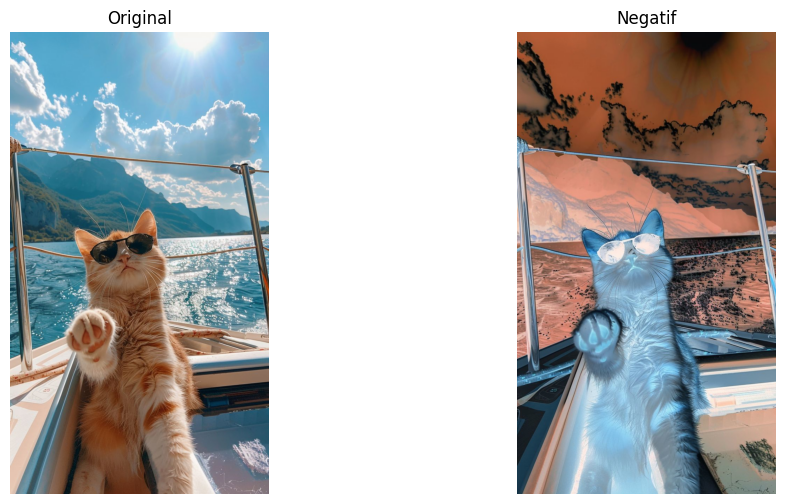

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload Gambar
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
img_bgr = cv2.imdecode(np.frombuffer(uploaded[file_name], np.uint8), cv2.IMREAD_COLOR)

# Proses: Identitas (Gambar Asli) & Negatif
img_identitas = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_negatif = 255 - img_bgr
img_negatif_rgb = cv2.cvtColor(img_negatif, cv2.COLOR_BGR2RGB)

# Tampilkan
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img_identitas), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(img_negatif_rgb), plt.title('Negatif'), plt.axis('off')
plt.show()

**TRANSFORMASI LOGARITMIK**

Saving Cat Wallpaper.jpg to Cat Wallpaper (6).jpg


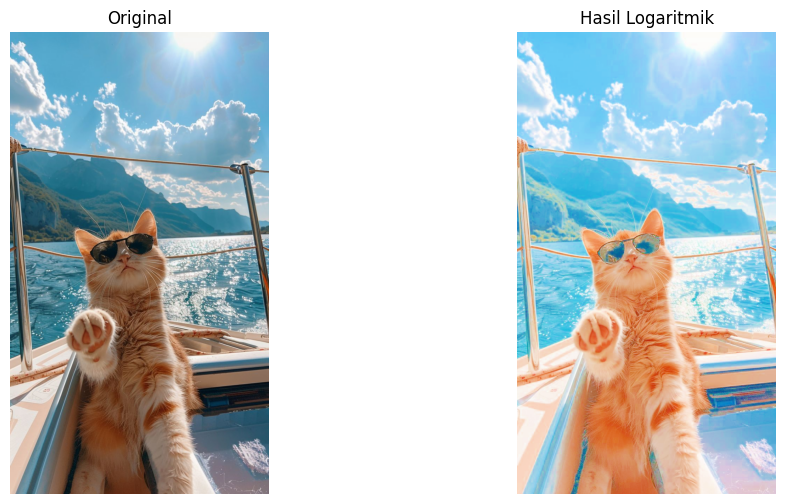

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload Gambar
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
img_bgr = cv2.imdecode(np.frombuffer(uploaded[file_name], np.uint8), cv2.IMREAD_COLOR)

# Proses Logaritmik pada Channel V (Kecerahan)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
v_float = v.astype(np.float64)
c = 255 / np.log(1 + np.max(v_float))
v_log = np.uint8(c * (np.log(1 + v_float)))

img_log = cv2.merge((h, s, v_log))
img_log_rgb = cv2.cvtColor(img_log, cv2.COLOR_HSV2RGB)
img_ori = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Tampilkan
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img_ori), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(img_log_rgb), plt.title('Hasil Logaritmik'), plt.axis('off')
plt.show()

**TRANSFORMASI POWER-LAW**

Saving Cat Wallpaper.jpg to Cat Wallpaper (7).jpg


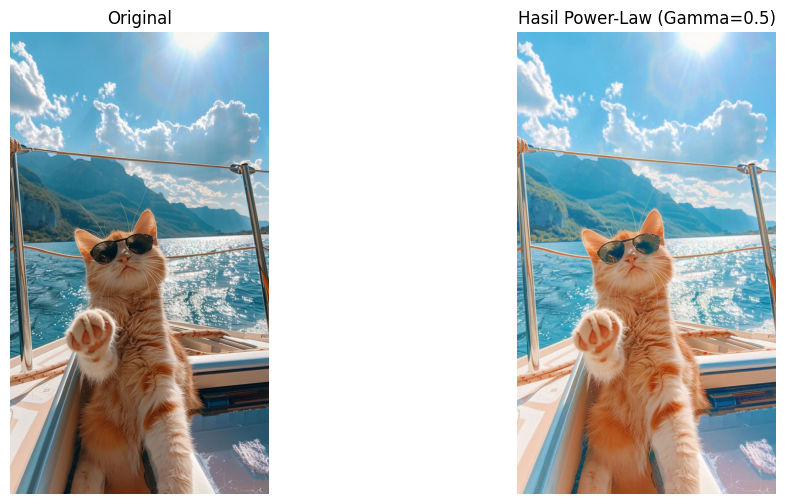

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload Gambar
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
img_bgr = cv2.imdecode(np.frombuffer(uploaded[file_name], np.uint8), cv2.IMREAD_COLOR)

# Parameter Gamma
gamma = 0.5 # Ganti ke 2.0 untuk efek gelap

# Proses Power-Law pada Channel V (Kecerahan)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
v_gamma = np.array(255 * (v / 255.0) ** gamma, dtype=np.uint8)

img_gamma = cv2.merge((h, s, v_gamma))
img_gamma_rgb = cv2.cvtColor(img_gamma, cv2.COLOR_HSV2RGB)
img_ori = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Tampilkan
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img_ori), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(img_gamma_rgb), plt.title(f'Hasil Power-Law (Gamma={gamma})'), plt.axis('off')
plt.show()

**TRANSFORMASI NEGATIF,LOGARITMIK,POWER-LAW**

Saving Cat Wallpaper.jpg to Cat Wallpaper (9).jpg


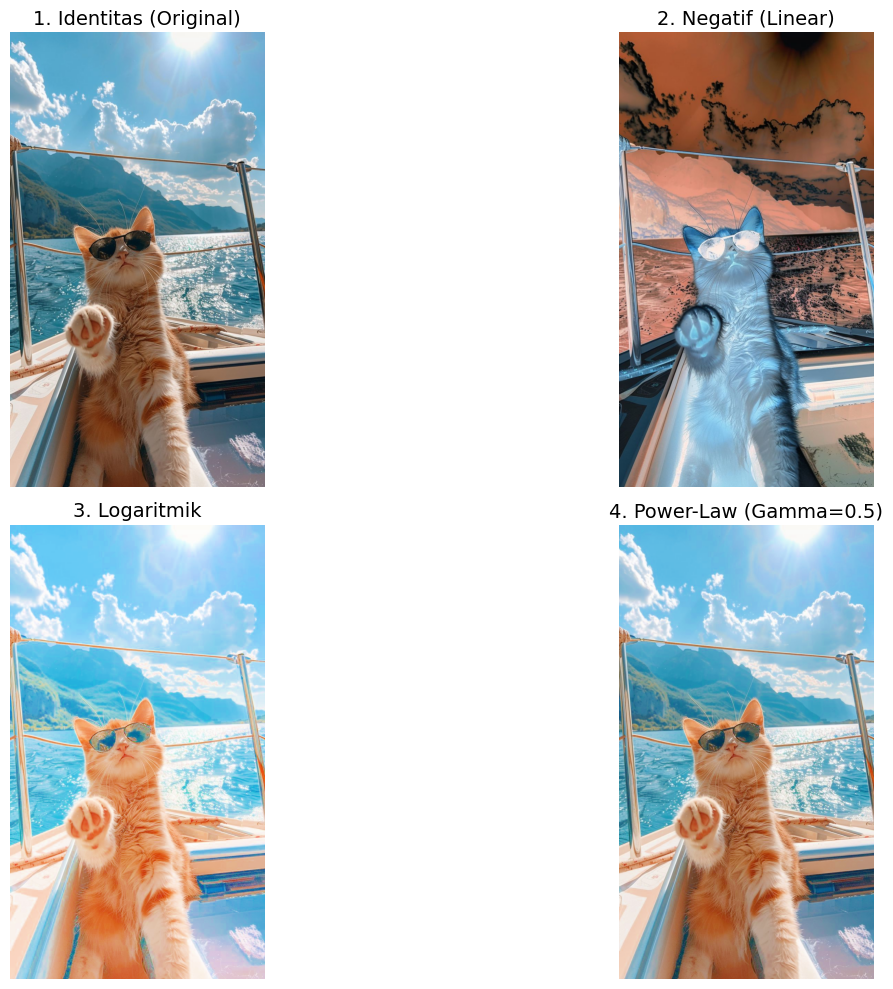

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- 1. UPLOAD MANUAL ---
uploaded = files.upload()
if not uploaded:
    print("Tidak ada file yang dipilih.")
else:
    file_name = list(uploaded.keys())[0]
    # Load gambar asli (BGR)
    img_bgr = cv2.imdecode(np.frombuffer(uploaded[file_name], np.uint8), cv2.IMREAD_COLOR)

    # Konversi ke RGB untuk tampilan Matplotlib (IDENTITAS)
    img_identitas = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # --- 2. PROSES TRANSFORMASI ---

    # A. Transformasi Negatif (Linear)
    img_negatif = 255 - img_bgr
    img_negatif_rgb = cv2.cvtColor(img_negatif, cv2.COLOR_BGR2RGB)

    # B. Transformasi Logaritmik (Gunakan HSV agar warna tidak rusak)
    hsv_log = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv_log)
    v_float = v.astype(np.float64)
    c_log = 255 / np.log(1 + np.max(v_float))
    v_log = np.uint8(c_log * (np.log(1 + v_float)))
    img_log_rgb = cv2.cvtColor(cv2.merge((h, s, v_log)), cv2.COLOR_HSV2RGB)

    # C. Transformasi Power-Law / Gamma (Gunakan HSV)
    gamma = 0.5  # < 1 mencerahkan, > 1 menggelapkan
    hsv_gamma = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv_gamma)
    v_gamma = np.array(255 * (v / 255.0) ** gamma, dtype=np.uint8)
    img_gamma_rgb = cv2.cvtColor(cv2.merge((h, s, v_gamma)), cv2.COLOR_HSV2RGB)

    # --- 3. VISUALISASI GABUNGAN ---
    titles = [
        '1. Identitas (Original)',
        '2. Negatif (Linear)',
        '3. Logaritmik',
        f'4. Power-Law (Gamma={gamma})'
    ]
    images = [img_identitas, img_negatif_rgb, img_log_rgb, img_gamma_rgb]

    plt.figure(figsize=(16, 10))
    for i in range(4):
        plt.subplot(2, 2, i + 1)
        plt.imshow(images[i])
        plt.title(titles[i], fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()